In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set figure background to white, edgecolor to black, and font size
plt.rcParams.update({
    'figure.facecolor': 'white',
    'figure.edgecolor': 'black',
    # 'figure.dpi': 100,
    'axes.facecolor': 'white',
    'font.size': 18
})

model_results=[
    'bnn_126-21-2',
    'distilled_126-21-2',
    'full_126-21-2',

    # 'bnn_126-42-2',
    # 'distilled_126-42-2',
    # 'full_126-42-2',
    
    # 'bnn_128-32-8-2',
    # 'distilled_128-32-8-2',
    # 'full_128-32-16-2',
]

In [86]:


def load_results(model_name: str) -> pd.DataFrame:
    """
    Reads results_{model_name}.csv with columns: metric, mean, std
    Returns a DataFrame indexed by metric, with renamed columns.
    """
    path = Path(f"results/{model_name}/results_{model_name}_UNSW-NB15-custom.csv")
    if not path.exists():
        raise FileNotFoundError(f"{path} not found.")
    df = pd.read_csv(path).set_index('metric')
    df = df.rename(
        columns={'mean': f'{model_name}_mean',
                 'std':  f'{model_name}_std'})
    return df

# Load into list of DataFrames
dfs = [load_results(m) for m in model_results]
# Concatenate horizontally
df_all = pd.concat(dfs, axis=1)
# Display the combined table
df_all

,bnn_126-21-2_mean,bnn_126-21-2_std,distilled_126-21-2_mean,distilled_126-21-2_std,full_126-21-2_mean,full_126-21-2_std
metric,,,,,,
accuracy,0.878638,0.0,0.908137,0.0,0.981567,0.0
precision,0.884551,0.0,0.894270,0.0,0.968204,0.0
recall,0.868563,0.0,0.923940,0.0,0.995512,0.0
f1,0.878602,0.0,0.908131,0.0,0.981567,0.0


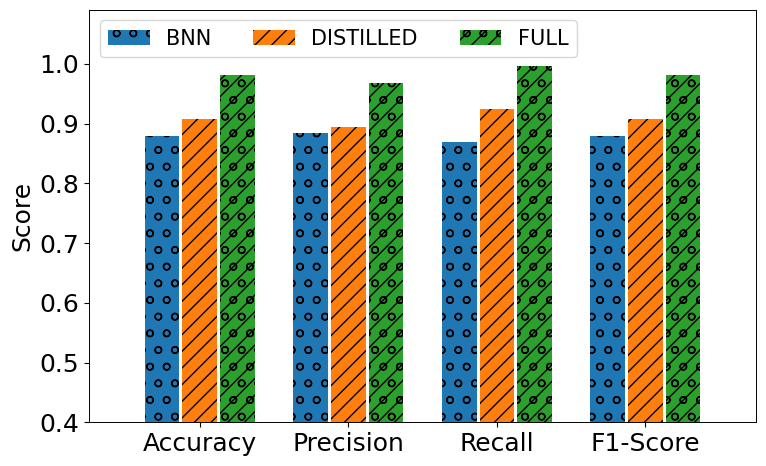

In [87]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

n_metrics = len(metrics)
n_models = len(model_results)

# X-axis positions for each metric group
x = np.arange(n_metrics)
# Width of each bar within a group
group_width = 0.7
bar_w = group_width / n_models

# Create figure and axis with black border
fig, ax = plt.subplots(figsize=(8, 5))

hatches = ['o', '//', 'o//']

# Plot bars for each model
for i, (model, h) in enumerate(zip(model_results, hatches)):
    means = [df_all.loc[m, f'{model}_mean'] for m in metrics]
    # stds  = [df_all.loc[m, f'{model}_std']  for m in metrics]
    ax.bar(
        x + (i - (n_models-1)/2)*(bar_w+0.02),
        means,
        width=bar_w,
        # yerr=stds,
        capsize=5,
        label=model.upper().split('_')[0],
        hatch=h
    )

# Add black border around axes
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(0.7)

# Add margins (de-zoom)
ax.margins(x=0.1, y=0.5)
ax.set_ylim(0.4, 1.09)

# Labels and styling
ax.set_xticks(x)
ax.set_xticklabels(labels)
# One-line legend with three columns
lagend = [model.split('_')[0] for model in model_results]
ax.legend(loc='upper left', ncol=n_models, fontsize='small')
# ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.set_ylabel('Score')
plt.tight_layout()
# plt.text(0.5, -0.15, "Figure 1: This is a caption below the plot.", ha='center', va='top', transform=plt.gca().transAxes)
plt.show()


In [88]:
out_path = 'results/comparison_tinies/model_comparison-UNSW-NB15-custom.png'
fig.savefig(out_path, edgecolor='black')
print(f"Saved plot as {out_path}")

Saved plot as results/comparison_tinies/model_comparison-UNSW-NB15-custom.png
